In [1]:
!pip install -q gymnasium stable-baselines3 sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 9.3 MB/s eta 0:00:00


In [1]:
 ## Cell 2 — Config
#
# CHANGES (v6):
#   • REMOVED: ATTACK_SEVERITY — severity is no longer part of RL logic at all
#   • ADDED: IDS_SEVERITY_MAP, ANOMALY_SEVERITY_THRESHOLDS (dashboard/reporting only)
#   • ADDED: get_anomaly_severity(), get_final_severity() (dashboard/reporting only)
#   • UPDATED: A3 threshold — conf > 0.8 (was 0.85), repeat > 2 (explicit), repeat > 1 for P/I/X
#   • REMOVED: A3_MIN_REPEAT / A3_MIN_CONF constants (now explicit literals in logic)


import numpy as np, random
from dataclasses import dataclass, field

# ── Actions ──────────────────────────────────────────────────────────────────
A0_MONITOR    = 0   # monitor + log
A1_RATE_LIMIT = 1   # rate limit على الـ source
A2_TEMP_BLOCK = 2   # temp block
A3_PERM_BLOCK = 3   # permanent block
# A4 = per-source DDoS mitigation  |  A5 = destination-side SYN protection
# Both fire together as a single RL action (discrete space stays at 5 actions)
A4_A5_DDOS    = 4   # DDoS response: A4 per-source meter + A5 dest SYN limit
N_ACTIONS     = 5

ACTION_NAMES = {
    0: "A0_MONITOR",
    1: "A1_RATE_LIMIT",
    2: "A2_TEMP_BLOCK",
    3: "A3_PERM_BLOCK",
    4: "A4_A5_DDOS",
}

# ── IDS attack encoding ───────────────────────────────────────────────────────
ATTACK_NORMAL   = 0
ATTACK_BRUTE    = 1
ATTACK_PASSWORD = 2
ATTACK_DOS      = 3
ATTACK_DDOS     = 4
ATTACK_SCAN     = 5
ATTACK_INJECT   = 6
ATTACK_XSS      = 7
N_ATTACK_TYPES  = 8

ATTACK_NAMES = {
    0: "normal",    1: "brute_force", 2: "password",  3: "dos",
    4: "ddos",      5: "scanning",    6: "injection",  7: "xss",
}

# ── IDS label → int mapping (من الـ LightGBM LabelEncoder) ───────────────────
IDS_LABEL_MAP = {
    "benign":    0,
    "brute force": 1,
    "password":  2,
    "dos":       3,
    "ddos":      4,
    "scanning":  5,
    "injection": 6,
    "xss":       7,
}
def ids_label_to_int(label: str) -> int:
    l = label.lower().strip()
    for k, v in IDS_LABEL_MAP.items():
        if k in l: return v
    return ATTACK_NORMAL

# ── Protocol ─────────────────────────────────────────────────────────────────
PROTO_MAP = {6: "TCP", 17: "UDP", 1: "ICMP", 58: "ICMP"}
def proto_to_str(p) -> str:
    try: return PROTO_MAP.get(int(p), "TCP")
    except: return "TCP"

# ── Anomaly thresholds & max ranges ──────────────────────────────────────────
ANOMALY_THRESHOLD = {"WebTcp": 19.0, "NonWebTcp": 5.0, "NonWebUDP": 6.63}
ANOMALY_MAX       = {"WebTcp": 30.0, "NonWebTcp": 10.0, "NonWebUDP": 10.0}

# ── Anomaly normalization ─────────────────────────────────────────────────────
# Piecewise:
#   raw = 0           → norm = 0.0
#   raw = threshold   → norm = 0.6  ← is_anomaly boundary
#   raw = max_score   → norm = 1.0
ANOMALY_NORMAL_MAX     = 0.3   # < 0.3 → benign → A0
ANOMALY_SUSPICIOUS_MAX = 0.6   # 0.3→0.6 → suspicious, admin review → A0
ANOMALY_NORM_BOUNDARY  = 0.6   # is_anomaly boundary (same value)

def normalize_anomaly_score(raw_score: float, model_key: str) -> float:
    thr = ANOMALY_THRESHOLD.get(model_key, 5.0)
    mx  = ANOMALY_MAX.get(model_key, 10.0)
    raw = max(0.0, float(raw_score))
    if raw <= thr:
        norm = (raw / thr) * ANOMALY_NORM_BOUNDARY
    else:
        extra = min((raw - thr) / max(mx - thr, 1e-6), 1.0)
        norm  = ANOMALY_NORM_BOUNDARY + extra * (1.0 - ANOMALY_NORM_BOUNDARY)
    return float(np.clip(norm, 0.0, 1.0))

def is_anomaly(norm: float) -> bool:
    return norm >= ANOMALY_NORM_BOUNDARY

# ── IDS thresholds ────────────────────────────────────────────────────────────
IDS_CONF_THR = 0.6   # minimum confidence for IDS to be considered "confirmed"

# ── DDoS conditions (all four must hold simultaneously) ──────────────────────
DDOS_MIN_SOURCES  = 10
DDOS_MIN_PRESSURE = 3.0
DDOS_MIN_CONNRATE = 50.0
DDOS_MIN_IDS_CONF = 0.6

# ── Network normalization caps ────────────────────────────────────────────────
PRESSURE_CAP  = 10.0
CONNRATE_CAP  = 200.0
CONNS_CAP     = 500.0
SOURCES_CAP   = 100.0
REPEAT_CAP    = 10.0

# ── Reward constants ──────────────────────────────────────────────────────────
R_FALSE_POS  = -50.0   # block على IP سليم
R_HESITATE   = -20.0   # سيب هجوم والشبكة مضغوطة
R_SAFE_VIOL  = -50.0   # خرق safety constraint
R_CORRECT    = +15.0   # action صح
R_ADJACENT   =  +5.0   # قريب بخطوة
R_UNDER_ACT  = -15.0   # رد ضعيف (يتضاعف مع التكرار)
R_OVER_ACT   = -15.0   # رد قوي أكتر من اللازم
R_BENIGN_OK  =  +5.0   # ترافيك سليم عدى صح
R_BONUS      = +30.0   # أنقذ السيرفر أو hybrid detection
R_STEP       =  -0.5   # penalty بسيط لكل خطوة

# ════════════════════════════════════════════════════════════════════════════
# ██  SEVERITY SYSTEM — DASHBOARD / REPORTING / EXPLANATION ONLY          ██
# ██  Must NOT be included in RL state. Must NOT affect RL decisions.     ██
# ════════════════════════════════════════════════════════════════════════════

# IDS attack type → severity label (for dashboard explanation layer)
IDS_SEVERITY_MAP = {
    ATTACK_NORMAL:   "LOW",
    ATTACK_BRUTE:    "MEDIUM",
    ATTACK_SCAN:     "MEDIUM",
    ATTACK_PASSWORD: "HIGH",
    ATTACK_INJECT:   "HIGH",
    ATTACK_XSS:      "HIGH",
    ATTACK_DOS:      "HIGH",
    ATTACK_DDOS:     "CRITICAL",
}

# Normalized anomaly score → severity label (for dashboard explanation layer)
ANOMALY_SEVERITY_THRESHOLDS = {
    "LOW":      (0.00, 0.50),
    "MEDIUM":   (0.50, 0.65),
    "HIGH":     (0.65, 0.80),
    "CRITICAL": (0.80, 1.00),
}

_SEVERITY_ORDER = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

def get_anomaly_severity(anomaly_score: float) -> str:
    """
    DASHBOARD ONLY — converts normalized anomaly score to severity label.
    Must NOT be used inside RL state, reward, or action selection.
    """
    score = float(np.clip(anomaly_score, 0.0, 1.0))
    for label, (lo, hi) in ANOMALY_SEVERITY_THRESHOLDS.items():
        if lo <= score < hi:
            return label
    return "CRITICAL"   # score == 1.0 edge case

def get_final_severity(ids_attack_type: int, anomaly_score: float) -> str:
    """
    DASHBOARD ONLY — fuses IDS severity and anomaly severity.
    Rules:
      • IDS detects attack AND anomaly_score >= 0.6 → upgrade IDS severity one level
      • IDS says NORMAL → use anomaly severity only
    Must NOT be used inside RL state, reward, or action selection.
    """
    ids_sev = IDS_SEVERITY_MAP.get(ids_attack_type, "LOW")
    anom_sev = get_anomaly_severity(anomaly_score)

    if ids_attack_type == ATTACK_NORMAL:
        # IDS says benign → trust anomaly detector
        return anom_sev

    # IDS detected an attack
    if anomaly_score >= 0.6:
        # Strong agreement → upgrade IDS severity by one level
        idx = _SEVERITY_ORDER.index(ids_sev)
        upgraded = _SEVERITY_ORDER[min(idx + 1, len(_SEVERITY_ORDER) - 1)]
        return upgraded

    return ids_sev   # IDS only, anomaly not significant

print("✅ Config loaded  (v6 — severity removed from RL; dashboard functions added)")
print(f"   Anomaly thresholds: WebTcp={ANOMALY_THRESHOLD['WebTcp']} (max {ANOMALY_MAX['WebTcp']}) | "
      f"NonWebTcp={ANOMALY_THRESHOLD['NonWebTcp']} (max {ANOMALY_MAX['NonWebTcp']}) | "
      f"NonWebUDP={ANOMALY_THRESHOLD['NonWebUDP']} (max {ANOMALY_MAX['NonWebUDP']})")

# Normalization self-check
for mk in ["WebTcp", "NonWebTcp", "NonWebUDP"]:
    thr = ANOMALY_THRESHOLD[mk]; mx = ANOMALY_MAX[mk]
    at_thr      = normalize_anomaly_score(thr,       mk)
    at_thr_plus = normalize_anomaly_score(thr * 1.02, mk)
    at_max      = normalize_anomaly_score(mx,         mk)
    print(f"   {mk}: threshold({thr})→{at_thr:.3f} | "
          f"threshold×1.02→{at_thr_plus:.3f} (is_anomaly={is_anomaly(at_thr_plus)}) | "
          f"max({mx})→{at_max:.3f}")

# Dashboard severity self-check
_sev_cases = [
    (ATTACK_NORMAL, 0.72, "HIGH"),     # Normal + anomaly 0.72 → HIGH
    (ATTACK_NORMAL, 0.85, "CRITICAL"), # Normal + anomaly 0.85 → CRITICAL
    (ATTACK_BRUTE,  0.30, "MEDIUM"),   # Brute Force, anomaly low → MEDIUM
    (ATTACK_BRUTE,  0.65, "HIGH"),     # Brute Force + anomaly ≥ 0.6 → HIGH
    (ATTACK_DOS,    0.70, "CRITICAL"), # DoS HIGH + anomaly ≥ 0.6 → CRITICAL
    (ATTACK_DDOS,   0.50, "CRITICAL"), # DDoS CRITICAL → stays CRITICAL
]
print("\n   Dashboard severity checks:")
for at, an, expected in _sev_cases:
    got = get_final_severity(at, an)
    mark = "✅" if got == expected else "❌"
    print(f"     {mark} {ATTACK_NAMES[at]:<12} anomaly={an:.2f} → {got} (expected {expected})")


# ## Cell 3 — Data Classes + State Builder
#
# CHANGES (v6):
#   • IDSOutput: REMOVED severity field
#   • NetworkState: bandwidth_util / cpu_load kept for dashboard; NOT in RL state
#   • IPHistory: was_blocked kept for reference; NOT in RL state
#   • HistoryStore.update(): repeat_count incremented on EVERY observation (not only on action)
#   • build_state(): removed severity, was_blocked, bandwidth_util, cpu_load
#   • STATE_DIM: 28 → 25  (−severity −was_blocked −bandwidth −cpu)
#   • make_ids(): removed ATTACK_SEVERITY reference


@dataclass
class IDSOutput:
    """
    Output of the IDS (LightGBM) model.
    severity is NOT included — it is computed separately for the dashboard only.
    """
    attack_type: int   = ATTACK_NORMAL
    confidence:  float = 0.0
    protocol:    str   = "TCP"

@dataclass
class AnomalyOutput:
    raw_score: float = 0.0
    model_key: str   = "WebTcp"   # WebTcp / NonWebTcp / NonWebUDP

@dataclass
class IPHistory:
    """
    Per-source-IP history.
    repeat_count = total number of times this IP has been observed (any action).
    was_blocked / block_count are tracked for reference / dashboard but NOT in RL state.
    """
    repeat_count: int = 0

    same_attack_count: int = 0
    last_attack_type: int = -1

    was_blocked: bool = False

    last_action: int = -1     # NEW
    block_count: int = 0

@dataclass
class NetworkState:
    """
    Destination / network metrics.
    dest_pressure_ratio, dest_new_conn_rate, conns_active_dest, unique_sources → in RL state.
    bandwidth_util, cpu_load → dashboard only, NOT in RL state.
    """
    dest_pressure_ratio: float = 1.0
    dest_new_conn_rate:  float = 0.0
    conns_active_dest:   int   = 0
    unique_sources:      int   = 1
    bandwidth_util:      float = 0.0   # dashboard only
    cpu_load:            float = 0.0   # dashboard only

# ── IP History Store (in-memory for training) ─────────────────────────────────
class HistoryStore:
    def __init__(self): self._d = {}

    def get(self, ip: str) -> IPHistory:
        return self._d.setdefault(ip, IPHistory())

    def update(self, ip: str, action: int, attack_type: int):
        """
        CHANGED (v6):
        repeat_count is now incremented on EVERY call, regardless of action.
        repeat_count = number of previous observations of this source IP.
          • First flow  : repeat_count was 0 when observed, becomes 1 after update
          • Second flow : repeat_count was 1 when observed, becomes 2 after update
          • ...
        A0_MONITOR still does NOT count as a "blocking" event (block_count unchanged).
        """
        h = self.get(ip)

        h.repeat_count += 1

        if attack_type == h.last_attack_type:
            h.same_attack_count += 1
        else:
            h.same_attack_count = 1

        h.last_attack_type = attack_type

        h.last_action = action

        if action != A0_MONITOR:
            h.was_blocked = True
            h.block_count += 1

    def reset(self, ip: str):
        self._d[ip] = IPHistory()

# ── State vector — 25 features ───────────────────────────────────────────────
# Breakdown:
#   attack_type one-hot        : 8   (N_ATTACK_TYPES)
#   ids_confidence             : 1
#   protocol [TCP, UDP, ICMP]  : 3
#   anomaly_norm               : 1
#   is_anomaly                 : 1
#   repeat_count (normalized)  : 1
#   last_action one-hot        : 5   (N_ACTIONS)
#   dest_pressure_ratio (norm) : 1
#   dest_new_conn_rate (norm)  : 1
#   conns_active_dest (norm)   : 1
#   unique_sources (norm)      : 1
#                              ───
#   TOTAL                      : 25
#
# REMOVED from v5 (was 28):
#   − ids.severity / 5.0       (1)  → dashboard only
#   − hist.was_blocked          (1)  → reference only
#   −
STATE_DIM = 28

def build_state(ids: IDSOutput, anom: AnomalyOutput,
                hist: IPHistory, net: NetworkState) -> np.ndarray:
    # Attack type one-hot (8)
    oh = np.zeros(N_ATTACK_TYPES, np.float32)
    oh[int(np.clip(ids.attack_type, 0, N_ATTACK_TYPES - 1))] = 1.0

    a_n = normalize_anomaly_score(anom.raw_score, anom.model_key)
    pr  = ids.protocol.upper()

    # Last-action one-hot (5)
    la = np.zeros(N_ACTIONS, np.float32)
    ids_uncertainty = 1 - ids.confidence
    anom_margin = abs(a_n - ANOMALY_NORM_BOUNDARY)
    if hist.last_action == -1:
        la[0] = 1.0
    else:
        la[hist.last_action] = 1.0
    v = np.concatenate([
        oh,                                                   # 8
        [np.clip(ids.confidence, 0, 1)],                     # 1  (NO severity)
        [pr == "TCP", pr == "UDP", pr == "ICMP"],             # 3
        [a_n, float(is_anomaly(a_n))],                       # 2
        [
        np.clip(hist.repeat_count / 5, 0, 1),
        np.clip(hist.same_attack_count / 5, 0, 1)
        ],
        [float(hist.repeat_count >=1)],
        la,                                                   # 5
        [np.clip(net.dest_pressure_ratio / PRESSURE_CAP, 0, 1),
         np.clip(net.dest_new_conn_rate  / CONNRATE_CAP,  0, 1),
         np.clip(net.conns_active_dest   / CONNS_CAP,     0, 1),
         np.clip(net.unique_sources      / SOURCES_CAP,   0, 1)],
        [1 - ids.confidence],
        [abs(a_n - ANOMALY_NORM_BOUNDARY)],
        ]).astype(np.float32)
    assert v.shape[0] == STATE_DIM, (
        f"STATE_DIM mismatch: got {v.shape[0]}, expected {STATE_DIM}"
    )
    return v

# ══════════════════════════════════════════════════════════════════════════════
# Anomaly Sub-Model Selection
# ══════════════════════════════════════════════════════════════════════════════
WEB_PORTS = {80, 443, 8080, 8443, 8000, 3000}

def select_anomaly_model(src_port: int, dst_port: int, protocol_num: int) -> str:
    """
    ┌──────────────┬────────────────────────────────────────────┐
    │  WebTcp      │  is_web_port=True  AND is_tcp=True         │
    │  NonWebTcp   │  is_web_port=False AND is_tcp=True         │
    │  NonWebUDP   │  is_web_port=False AND (is_udp OR is_icmp) │
    └──────────────┴────────────────────────────────────────────┘
    """
    is_web_port = (dst_port in WEB_PORTS) or (src_port in WEB_PORTS)
    is_tcp      = (protocol_num == 6)
    is_udp      = (protocol_num == 17)
    is_icmp     = (protocol_num in (1, 58))

    if is_web_port and is_tcp:
        return "WebTcp"
    elif (not is_web_port) and is_tcp:
        return "NonWebTcp"
    elif (not is_web_port) and (is_udp or is_icmp):
        return "NonWebUDP"
    else:
        return "NonWebTcp"   # safe fallback

# Verify select_anomaly_model
_sel_tests = [
    (1234, 443,  6,  "WebTcp",    "HTTPS TCP"),
    (1234, 80,   6,  "WebTcp",    "HTTP TCP"),
    (1234, 8080, 6,  "WebTcp",    "HTTP-alt TCP"),
    (1234, 22,   6,  "NonWebTcp", "SSH TCP"),
    (1234, 21,   6,  "NonWebTcp", "FTP TCP"),
    (1234, 3306, 6,  "NonWebTcp", "MySQL TCP"),
    (1234, 53,   17, "NonWebUDP", "DNS UDP"),
    (1234, 1234, 17, "NonWebUDP", "Custom UDP"),
    (1234, 1234, 1,  "NonWebUDP", "ICMP"),
]
_all_ok = True
for sp, dp, pr, exp, lbl in _sel_tests:
    got = select_anomaly_model(sp, dp, pr)
    if got != exp: _all_ok = False; print(f"❌ {lbl}: got {got} expected {exp}")
print(f"✅ select_anomaly_model — {'all OK' if _all_ok else 'ERRORS!'}")

# ── Bridge functions ───────────────────────────────────────────────────────────
def make_ids(label: str, confidence: float, protocol_raw=6) -> IDSOutput:
    """
    IDS LightGBM string output → IDSOutput.
    CHANGED (v6): severity is no longer included in IDSOutput.
    Use get_final_severity() separately for dashboard purposes.
    """
    at = ids_label_to_int(label)
    return IDSOutput(at, float(confidence), proto_to_str(protocol_raw))

def make_anomaly(api_resp: dict) -> AnomalyOutput:
    """
    Anomaly FastAPI response → AnomalyOutput.
    api_resp = {"model": "WebTcp"/"NonWebTcp"/"NonWebUDP",
                "anomaly_score": float, "is_anomaly": bool}
    """
    return AnomalyOutput(
        raw_score = float(api_resp.get("anomaly_score", 0.0)),
        model_key = api_resp.get("model", "WebTcp"),
    )

def build_state_from_flow(flow_meta: dict, ids_label: str, ids_conf: float,
                           anomaly_resp: dict, history_store: HistoryStore,
                           net: NetworkState) -> np.ndarray:
    """
    Full bridge for VM inference:
    flow_meta    = {"src_ip", "dst_ip", "src_port", "dst_port", "protocol", ...}
    ids_label    = string from LightGBM (e.g. "Brute Force")
    ids_conf     = max(predict_proba(...)[0])
    anomaly_resp = dict from Anomaly API
    """
    ids     = make_ids(ids_label, ids_conf, flow_meta.get("protocol", 6))
    anomaly = make_anomaly(anomaly_resp)
    src_ip  = flow_meta.get("src_ip", "0.0.0.0")
    history = history_store.get(src_ip)
    return build_state(ids, anomaly, history, net)

print(f"✅ State builder OK — STATE_DIM={STATE_DIM}")
print(f"   Feature breakdown: 8(attack) + 1(conf) + 3(proto) + 2(anomaly) "
      f"+ 1(repeat) + 5(last_action) + 4(network) = {STATE_DIM}")


# ## Cell 4 — Decision Logic
#
# CHANGES (v6):
#   • a3_ok(): updated thresholds
#       - Strong Agreement (Rule 12): ids.confidence > 0.8, anomaly > 0.5, rc > 2
#       - Decision Table (P/I/X): rc > 1  (was rc >= A3_MIN_REPEAT)
#   • recommended(): DDoS → Strong Agreement → IDS table → Anomaly-only
#       - A0_MONITOR allowed ONLY when IDS confidence < 0.6 AND anomaly < 0.6
#       - Brute/Scan/DoS: rc == 0 → A1, else → A2
#       - Password/Inject/XSS: rc == 0 → A2, rc > 1 → A3 (via a3_ok)
#       - Anomaly-only Case C: rc > 2 → A2 (was rc > 2 — UNCHANGED)
#   • No severity references remain in any decision function


# ── Helper predicates ────────────────────────────────────────────────────────
def ids_ok(ids: IDSOutput) -> bool:
    """True when IDS confidently identifies an attack (not just anomaly)."""
    return ids.attack_type != ATTACK_NORMAL and ids.confidence > IDS_CONF_THR

def ddos_cond(ids: IDSOutput, net: NetworkState) -> bool:
    """
    Explicit DDoS detection rule (all four conditions must hold):
      unique_sources > 10
      AND dest_pressure_ratio > 3.0
      AND dest_new_conn_rate >= 50.0
      AND ids.confidence > 0.6
    """
    return (
        ids.attack_type   == ATTACK_DDOS
        and net.unique_sources      >  DDOS_MIN_SOURCES
        and net.dest_pressure_ratio >  DDOS_MIN_PRESSURE
        and net.dest_new_conn_rate  >= DDOS_MIN_CONNRATE
        and ids.confidence          >  DDOS_MIN_IDS_CONF
    )

# ── a3_ok — determines when A3_PERM_BLOCK is allowed ────────────────────────
def a3_ok(ids: IDSOutput, a_n: float, h: IPHistory) -> bool:
    """
    Returns True when A3 (permanent block) is allowed and justified.

    Two triggering rules:

    Rule 12 — Strong Agreement Escalation:
        IDS confidence > 0.8  AND  anomaly_score > 0.5  AND  repeat_count > 2
        Applies to ANY confirmed attack type (overrides decision table).

    Decision Table — Password / Injection / XSS:
        IDS confirmed  AND  attack in {password, injection, xss}  AND  repeat_count > 1
        (Second+ repetition of a high-severity attack justifies permanent block.)

    Important: A3 is NEVER allowed for anomaly-only traffic
               (IDS confidence < 0.6) — enforced via the mask.
    """
    rc = h.repeat_count
    at = ids.attack_type

    # Rule 12: Strong Agreement — any confirmed attack type
    if ids.confidence > 0.8 and a_n > 0.5 and rc > 2:
        return True

    # Decision Table: Password / Injection / XSS with repetition
    if ids_ok(ids) and at in (ATTACK_PASSWORD, ATTACK_INJECT, ATTACK_XSS):
        if rc > 1:      # repeat_count > 1 → third+ encounter
            return True

    return False

# ── Safety mask ──────────────────────────────────────────────────────────────
def get_mask(ids: IDSOutput, a_n: float, h: IPHistory,
             net: NetworkState, whitelisted: bool = False) -> list:
    """
    Action mask — prevents RL from selecting structurally disallowed actions.
    Returns list[bool] of length N_ACTIONS.
    """
    m = [True] * N_ACTIONS

    if whitelisted:
        return [a == A0_MONITOR for a in range(N_ACTIONS)]

    # Block A3 when not justified
    if not a3_ok(ids, a_n, h):
        m[A3_PERM_BLOCK] = False

    # Block A4_A5_DDOS when DDoS conditions are not met
    if not ddos_cond(ids, net):
        m[A4_A5_DDOS] = False

    return m

# ── Recommended action — decision table ──────────────────────────────────────
def recommended(ids: IDSOutput, a_n: float, h: IPHistory,
                net: NetworkState) -> int:
    """
    Decision table (v6 — fully aligned with spec).

    Priority order:
        1. DDoS (A4+A5) — always takes precedence when conditions met
        2. Strong Agreement Rule 12 (A3) — escalates any confirmed attack
        3. IDS-confirmed attack table (per attack type)
        4. Anomaly-only cases (IDS confidence < 0.6)

    A0_MONITOR is returned ONLY when:
        • IDS does not confidently identify an attack (conf < 0.6)
        • anomaly_score < 0.6
        • No confirmed malicious behavior

    Decision table per attack type:
        Brute Force   : rc==0 → A1   | rc>0  → A2
        Password      : rc==0 → A2   | rc>1  → A3   | rc==1 → A2
        Scanning      : rc==0 → A1   | rc>0  → A2
        Injection     : rc==0 → A2   | rc>1  → A3   | rc==1 → A2
        XSS           : rc==0 → A2   | rc>1  → A3   | rc==1 → A2
        DoS           : rc==0 → A1   | rc>0  → A2
        DDoS          : A4_A5_DDOS (when ddos_cond met)

    Anomaly-only (IDS conf < 0.6):
        Case A: 0.30 ≤ a_n < 0.60                   → A0_MONITOR
        Case B: a_n ≥ 0.60 AND repeat_count ≤ 2     → A1_RATE_LIMIT
        Case C: a_n ≥ 0.60 AND repeat_count > 2      → A2_TEMP_BLOCK
        A3 never allowed for anomaly-only traffic.
    """
    A0, A1, A2, A3, A4A5 = (A0_MONITOR, A1_RATE_LIMIT,
                              A2_TEMP_BLOCK, A3_PERM_BLOCK, A4_A5_DDOS)
    rc = h.repeat_count
    at = ids.attack_type
    if at == ATTACK_DDOS:
      print("=== DDoS DEBUG ===")
      print("attack_type =", at)
      print("ATTACK_DDOS =", ATTACK_DDOS)
      print("unique_sources =", net.unique_sources)
      print("dest_pressure =", net.dest_pressure_ratio)
      print("new_conn_rate =", net.dest_new_conn_rate)
      print("confidence =", ids.confidence)
      print("ddos_cond =", ddos_cond(ids, net))

    if at == ATTACK_DDOS and ddos_cond(ids, net):
        return A4A5
    # ── Priority 1: DDoS distributed attack ──────────────────────────────────
    if at == ATTACK_DDOS and ddos_cond(ids, net):
        return A4A5

    # ── Priority 2: Strong Agreement (Rule 12) — escalate to A3 ─────────────
    # Applies when IDS + anomaly + history all agree strongly.
    # Checked BEFORE attack-specific table so it can escalate any attack type.
    if ids.confidence > 0.8 and a_n > 0.5 and rc > 2:
        return A3

    # ── Priority 3: IDS-confirmed attack table ────────────────────────────────
    if ids_ok(ids):
        if at == ATTACK_BRUTE:
            # First occurrence → rate limit; any repeat → temp block
            return A1 if rc == 0 else A2

        elif at == ATTACK_PASSWORD:
            # High-severity: block from first encounter, permanent block on repeat>1
            return A3 if a3_ok(ids, a_n, h) else A2

        elif at == ATTACK_SCAN:
            return A1 if rc == 0 else A2

        elif at in (ATTACK_INJECT, ATTACK_XSS):
            # Critical-severity: block from first encounter, permanent block on repeat>1
            return A3 if a3_ok(ids, a_n, h) else A2

        elif at == ATTACK_DOS:
            return A1 if rc == 0 else A2

        else:
            # Unknown IDS-confirmed attack → conservative rate limit
            return A1

    # ── Priority 4: Anomaly-only (IDS confidence < 0.6) ─────────────────────
    # Case: below suspicious threshold → benign behavior → monitor only
    if a_n < ANOMALY_NORMAL_MAX:        # < 0.3 → clearly benign
        return A0
    if a_n < ANOMALY_SUSPICIOUS_MAX:    # 0.3 ≤ a_n < 0.6 → suspicious, needs review
        return A0                        # Case A

    # a_n ≥ 0.6 → anomaly confirmed
    if rc <= 2:
        return A1   # Case B: first/second/third encounter → rate limit
    return A2       # Case C: established repeat offender → temp block
    # Note: A3 is never recommended for anomaly-only (no IDS confirmation)

# ── Benign helper ─────────────────────────────────────────────────────────────
def benign(ids: IDSOutput, a_n: float, is_mal: bool = False) -> bool:
    """
    Traffic is considered benign when:
      - Not labeled malicious by the simulator (is_mal=False)
      - IDS does not flag it as an attack
    High anomaly with is_mal=False is treated as false alarm → still benign.
    """
    return (not is_mal) and (ids.attack_type == ATTACK_NORMAL)

# ── Reward function ───────────────────────────────────────────────────────────
def compute_reward(action: int, ids: IDSOutput, a_n: float,
                   h: IPHistory, net: NetworkState, is_mal: bool):
    """
    No severity used anywhere in reward computation.
    Reward depends only on: action, ids (type+conf), anomaly_norm, history, network, is_mal.
    """
    info = {}
    rec  = recommended(ids, a_n, h, net)
    mask = get_mask(ids, a_n, h, net)
    rw   = R_STEP
    info["step"] = R_STEP

    # Safety violation
    if not mask[action]:
        rw += R_SAFE_VIOL
        info["safety_viol"] = R_SAFE_VIOL
        return rw, info

    # False positive — action on benign traffic
    if benign(ids, a_n, is_mal):
        if action == A0_MONITOR:
            rw += R_BENIGN_OK
            info["benign_ok"] = R_BENIGN_OK
        else:
            rw += R_FALSE_POS
            info["false_pos"] = R_FALSE_POS
        return rw, info

    # Unclear suspicious (not malicious, IDS uncertain, anomaly below boundary)
    if not is_mal and not ids_ok(ids) and a_n < ANOMALY_NORM_BOUNDARY:
        rw += (R_BENIGN_OK if action == A0_MONITOR else R_OVER_ACT)
        return rw, info

    # Real attack
    if action == rec:
        if rec == A1_RATE_LIMIT:
            rw += 50
        elif rec == A2_TEMP_BLOCK:
            rw += 30
        elif rec == A3_PERM_BLOCK:
            rw += 20
        elif rec == A4_A5_DDOS:
            rw += 40
        else:
            rw += R_CORRECT

    elif action < rec:
        mult = 1.0 + min(h.same_attack_count, 5) * 2.0
        p = R_UNDER_ACT * mult
        rw += p
        info["under_react"] = p

    else:
        rw += R_OVER_ACT
        info["over_react"] = R_OVER_ACT

    # Bonus: hesitation under network pressure
    if action == A0_MONITOR and net.dest_pressure_ratio > 2.0 and rec != A0_MONITOR:
        rw += R_HESITATE
        info["hesitate"] = R_HESITATE

    # Bonus: correct action saved a stressed server
    if action == rec and action != A0_MONITOR and net.dest_pressure_ratio > 2.0:
        rw += R_BONUS
        info["saved_server"] = R_BONUS

    # Bonus: anomaly-only detection (IDS uncertain but anomaly confirmed correct action)
    if action == rec and action != A0_MONITOR and not ids_ok(ids) and is_anomaly(a_n):
        rw += R_BONUS
        info["hybrid_bonus"] = R_BONUS

    # DDoS response bonus
    if action == A4_A5_DDOS and ids.attack_type == ATTACK_DDOS:
        rw += 100

    # Adjacent action bonus: if action is exactly one step above recommended, encourage it
    # if action == rec + 1 and rec < A3_PERM_BLOCK:
    #     rw += R_ADJACENT
    #     info["adjacent"] = R_ADJACENT
    if (
    rec == A1_RATE_LIMIT
    and ids_ok(ids)
    and action == A2_TEMP_BLOCK
):
        rw -= 40
    if rec == A1_RATE_LIMIT and action > A1_RATE_LIMIT:
        rw -= 60
        info["a1_to_stronger"] = -40
    if action == rec + 1 and rec >= A2_TEMP_BLOCK:
        rw += R_ADJACENT
    if (
          rec == A1_RATE_LIMIT
          and h.repeat_count == 0
          and action == A2_TEMP_BLOCK
      ):
          rw -= 30
    if (
    not ids_ok(ids)
    and is_anomaly(a_n)
    and h.repeat_count <= 2
    and action == A2_TEMP_BLOCK
  ):
      rw -= 100
    if (
      not ids_ok(ids)
      and is_anomaly(a_n)
      and h.repeat_count >2
      and action == A2_TEMP_BLOCK
  ):
      rw += 40
      info["anom_repeat_bonus"] = 40
    if rec == A4_A5_DDOS and action != A4_A5_DDOS:
        rw -= 100
        info["missed_ddos"] = -200
    return rw, info
print("✅ Decision logic loaded  (v6 — no severity; repeat_count = total observations)")


# ## Cell 5 — Scenario Generator
#
# CHANGES (v6):
#   • REMOVED: sv (severity) field from all scenario dicts
#   • REMOVED: bw (bandwidth_util), cpu (cpu_load) fields from all scenario dicts
#   • sample(): no longer returns severity, bandwidth, cpu
#   • repeat_count ranges: represent total prior observations of the IP
#     (repeat scenarios use rc=(2,5) to reliably trigger rc>1 escalation)
#   • NOTE: is_first_seen is NOT added (repeat_count==0 already encodes first observation)


SCENS = [
    # ── Benign traffic ────────────────────────────────────────────────────────
    dict(n="benign",        w=0.07, at=ATTACK_NORMAL,   mal=False, mk="WebTcp",    proto=6,
         cf=(0.0, 0.30),    af=(0.0, 0.70),   us=(1, 4),   dp=(0.4, 1.3), nc=(0, 8),    rc=(0, 0)),

    # ── Brute Force ───────────────────────────────────────────────────────────
    dict(n="brute_first",   w=0.15, at=ATTACK_BRUTE,    mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.62, 0.95),   af=(1.02, 1.25),  us=(1, 3),   dp=(0.9, 2.2), nc=(5, 25),   rc=(0, 0)),
    dict(n="brute_repeat",  w=0.03, at=ATTACK_BRUTE,    mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.65, 0.95),   af=(1.02, 1.28),  us=(1, 3),   dp=(1.1, 2.5), nc=(8, 30),   rc=(2, 5)),

    # ── Password Attack ───────────────────────────────────────────────────────
    dict(n="pass_first",    w=0.06, at=ATTACK_PASSWORD, mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.65, 0.97),   af=(1.02, 1.30),  us=(1, 3),   dp=(0.9, 2.0), nc=(3, 15),   rc=(0, 0)),
    dict(n="pass_repeat",   w=0.09, at=ATTACK_PASSWORD, mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.70, 0.97),   af=(1.03, 1.30),  us=(1, 3),   dp=(1.0, 2.2), nc=(3, 15),   rc=(2, 5)),

    # ── Scanning ──────────────────────────────────────────────────────────────
    dict(n="scan_first",    w=0.15, at=ATTACK_SCAN,     mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.62, 0.90),   af=(1.02, 1.25),  us=(1, 4),   dp=(0.8, 1.8), nc=(8, 40),   rc=(0, 0)),
    dict(n="scan_repeat",   w=0.03, at=ATTACK_SCAN,     mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.62, 0.90),   af=(1.02, 1.28),  us=(1, 4),   dp=(0.9, 2.0), nc=(10, 45),  rc=(2, 5)),

    # ── Injection ─────────────────────────────────────────────────────────────
    dict(n="inject_first",  w=0.04, at=ATTACK_INJECT,   mal=True,  mk="WebTcp",    proto=6,
         cf=(0.68, 0.98),   af=(1.02, 1.20),  us=(1, 3),   dp=(0.9, 2.0), nc=(2, 12),   rc=(0, 0)),
    dict(n="inject_rpt",    w=0.06, at=ATTACK_INJECT,   mal=True,  mk="WebTcp",    proto=6,
         cf=(0.75, 0.98),   af=(1.02, 1.22),  us=(1, 3),   dp=(1.0, 2.2), nc=(2, 12),   rc=(2, 5)),

    # ── XSS ───────────────────────────────────────────────────────────────────
    dict(n="xss_first",     w=0.08, at=ATTACK_XSS,      mal=True,  mk="WebTcp",    proto=6,
         cf=(0.68, 0.98),   af=(1.02, 1.20),  us=(1, 3),   dp=(0.9, 2.0), nc=(2, 12),   rc=(0, 0)),
    dict(n="xss_rpt",       w=0.06, at=ATTACK_XSS,      mal=True,  mk="WebTcp",    proto=6,
         cf=(0.75, 0.98),   af=(1.02, 1.22),  us=(1, 3),   dp=(1.0, 2.2), nc=(2, 12),   rc=(2, 5)),

    # ── DoS ───────────────────────────────────────────────────────────────────
    dict(n="dos_first",     w=0.15, at=ATTACK_DOS,      mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.62, 0.92),   af=(1.02, 1.30),  us=(1, 5),   dp=(1.5, 3.4), nc=(15, 45),  rc=(0, 0)),
    dict(n="dos_rpt",       w=0.03, at=ATTACK_DOS,      mal=True,  mk="NonWebTcp", proto=6,
         cf=(0.65, 0.92),   af=(1.02, 1.30),  us=(1, 5),   dp=(1.8, 3.8), nc=(18, 45),  rc=(2, 5)),

    # ── DDoS — all four conditions guaranteed above threshold ─────────────────
    dict(n="ddos",          w=0.15, at=ATTACK_DDOS,     mal=True,  mk="NonWebUDP", proto=17,
         cf=(0.65, 0.95),   af=(1.02, 1.28),  us=(12, 90), dp=(3.2, 9.0), nc=(55, 190), rc=(0, 3)),

    # ── Anomaly-only (IDS not confident) ─────────────────────────────────────
    # Case A: anomaly 0.3→0.6, suspicious, not confirmed → A0
    dict(n="anom_unclear",  w=0.08, at=ATTACK_NORMAL,   mal=False, mk="NonWebTcp", proto=6,
         cf=(0.0, 0.35),    af=(0.5, 0.99),   us=(1, 4),   dp=(0.6, 1.6), nc=(3, 15),   rc=(0, 3)),

    # anomaly confirmed + first time
    dict(
        n="anom_clear_first",
        w=0.15,
        at=ATTACK_NORMAL,
        mal=True,
        mk="NonWebUDP",
        proto=17,
        cf=(0.0, 0.40),
        af=(1.02, 1.28),
        us=(1, 4),
        dp=(1.2, 2.8),
        nc=(10, 35),
        rc=(0, 0)
    ),

    # anomaly confirmed + repeat offender
    dict(
        n="anom_clear_repeat",
        w=0.03,
        at=ATTACK_NORMAL,
        mal=True,
        mk="NonWebUDP",
        proto=17,
        cf=(0.0, 0.40),
        af=(1.02, 1.28),
        us=(1, 4),
        dp=(1.2, 2.8),
        nc=(10, 35),
        rc=(3, 5)
    )
]
_W = [s["w"] for s in SCENS]
print(f"weights sum = {sum(_W):.3f}")

def sample(rng: random.Random) -> dict:
    """
    Samples a scenario. Returns dict without severity, bandwidth, or cpu.
    repeat_count (init_rc) = number of prior observations of this IP (total, any action).
    """
    phase_bias = rng.random()
    if phase_bias < 0.3:
        pool = [s for s in SCENS if "first" in s["n"]]
    elif phase_bias < 0.6:
          pool = [s for s in SCENS if "repeat" in s["n"]]
    else:
          pool = SCENS

    s = rng.choices(pool, k=1)[0]
    u = lambda r: rng.uniform(r[0], r[1])
    return dict(
        name          = s["n"],
        attack_type   = s["at"],
        malicious     = s["mal"],
        model_key     = s["mk"],
        protocol      = proto_to_str(s["proto"]),
        ids_conf      = u(s["cf"]),
        anomaly_factor= u(s["af"]),          # raw = factor × threshold
        unique_src    = int(round(u(s["us"]))),
        dest_pressure = u(s["dp"]),
        new_conn_rate = u(s["nc"]),
        conns         = int(round(u((1, 60)))),
        init_rc       = int(round(u(s["rc"]))),
        # severity, bandwidth, cpu intentionally EXCLUDED
    )

# Sanity checks
_r = random.Random(0)
_s = [sample(_r) for _ in range(3000)]
print("✅ Scenario generator OK  (v6 — no sv/bw/cpu; repeat_count = total observations)")
print(f"   DDoS%                     = {sum(1 for x in _s if x['name']=='ddos')/30:.1f}%")
print(f"   Episodes with init_rc > 0 = {sum(1 for x in _s if x['init_rc']>0)/30:.1f}%")

for mk, af in [("WebTcp", 1.03), ("NonWebTcp", 1.03), ("NonWebUDP", 1.03)]:
    raw = af * ANOMALY_THRESHOLD[mk]
    n   = normalize_anomaly_score(raw, mk)
    print(f"   {mk}: raw={raw:.2f} → norm={n:.3f} → is_anomaly={is_anomaly(n)}")


# ## Cell 6 — Gymnasium Environment
#
# CHANGES (v6):
#   • reset(): IDSOutput built without severity; NetworkState built without bw/cpu
#   • _feedback(): removed bandwidth_util and cpu_load dynamic updates
#   • HistoryStore.update() now always increments repeat_count (see Cell 3)


import gymnasium as gym
from gymnasium import spaces

MAX_STEPS = 6
MITIG = {
    A0_MONITOR: 1.0, A1_RATE_LIMIT: 0.50,
    A2_TEMP_BLOCK: 0.08, A3_PERM_BLOCK: 0.02, A4_A5_DDOS: 0.30,
}
TERMINAL = {

    A2_TEMP_BLOCK,
    A3_PERM_BLOCK
}

class NetKnightEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, seed=None):
        super().__init__()
        self.action_space      = spaces.Discrete(N_ACTIONS)
        self.observation_space = spaces.Box(0.0, 1.0, (STATE_DIM,), np.float32)
        self._rng   = random.Random(seed)
        self._store = HistoryStore()
        self._reset_ep_vars()

    def _reset_ep_vars(self):
        self._ip  = None
        self._ids = None
        self._af  = 0.0
        self._mk  = "WebTcp"
        self._net = None
        self._mal = False
        self._sc  = ""
        self._steps = 0
        self._ep    = 0

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = random.Random(seed)
        self._ep += 1
        self._ip = (f"10.{self._ep % 250}."
                    f"{self._rng.randint(0,255)}.{self._rng.randint(1,254)}")
        self._store.reset(self._ip)

        sc = sample(self._rng)
        self._sc  = sc["name"]
        self._mal = sc["malicious"]
        self._mk  = sc["model_key"]
        self._af  = sc["anomaly_factor"]

        # IDSOutput — NO severity (v6)
        self._ids = IDSOutput(
            attack_type = sc["attack_type"],
            confidence  = sc["ids_conf"],
            protocol    = sc["protocol"],
        )

        # NetworkState — NO bandwidth/cpu in construction (v6); they default to 0.0
        self._net = NetworkState(
            dest_pressure_ratio = sc["dest_pressure"],
            dest_new_conn_rate  = sc["new_conn_rate"],
            conns_active_dest   = sc["conns"],
            unique_sources      = sc["unique_src"],
        )

        # Pre-populate history if this is a "known" IP (init_rc > 0)
        if sc["init_rc"] > 0:
            h = self._store.get(self._ip)

            h.repeat_count = sc["init_rc"]
            h.same_attack_count = sc["init_rc"]
            h.last_attack_type = sc["attack_type"]

            h.was_blocked = True
            h.last_action = A1_RATE_LIMIT

        self._steps = 0
        return self._obs(), {"scenario": self._sc}

    def step(self, action: int):
        action = int(action)
        self._steps += 1
        h   = self._store.get(self._ip)
        a_n = normalize_anomaly_score(
                  self._af * ANOMALY_THRESHOLD[self._mk], self._mk)

        rw, info = compute_reward(action, self._ids, a_n, h, self._net, self._mal)

        self._feedback(action)
        self._store.update(
        self._ip,
        action,
        self._ids.attack_type)

        term  = self._resolved(action)
        trunc = self._steps >= MAX_STEPS
        info.update({"scenario": self._sc, "action": ACTION_NAMES[action]})
        return self._obs(), rw, term, trunc, info

    def action_masks(self) -> np.ndarray:
        h   = self._store.get(self._ip)
        a_n = normalize_anomaly_score(
                  self._af * ANOMALY_THRESHOLD[self._mk], self._mk)
        return np.array(get_mask(self._ids, a_n, h, self._net), dtype=bool)

    def _obs(self):
        h = self._store.get(self._ip)
        return build_state(
            self._ids,
            AnomalyOutput(self._af * ANOMALY_THRESHOLD[self._mk], self._mk),
            h,
            self._net,
        )

    def _feedback(self, action: int):
        """
        Update network state based on action effectiveness.
        CHANGED (v6): bandwidth_util and cpu_load no longer updated here
                      (removed from RL state; no training signal needed).
        """
        mit = MITIG[action]

        # A1 against distributed DDoS is nearly ineffective → very small mitigation
        if (self._ids.attack_type == ATTACK_DDOS
                and self._net.unique_sources > DDOS_MIN_SOURCES
                and action == A1_RATE_LIMIT):
            mit = 0.97

        if self._mal:
            if mit < 1.0:
                self._net.dest_pressure_ratio = max(
                    0.3, self._net.dest_pressure_ratio * mit)
                self._net.dest_new_conn_rate = max(
                    0.0, self._net.dest_new_conn_rate * mit)
                self._af = max(0.05, self._af * 0.55)
                if action in (A2_TEMP_BLOCK, A3_PERM_BLOCK):
                    self._net.unique_sources = max(1, self._net.unique_sources - 1)
                elif action == A4_A5_DDOS:
                    self._net.unique_sources = max(
                        1, int(self._net.unique_sources * 0.85))
            else:
                # Ineffective action → attack escalates
                self._net.dest_pressure_ratio = min(
                    PRESSURE_CAP, self._net.dest_pressure_ratio * 1.18)
                self._net.dest_new_conn_rate = min(
                    CONNRATE_CAP, self._net.dest_new_conn_rate * 1.12)
                self._af = min(2.0, self._af * 1.08)
        else:
            # Benign traffic — small random pressure fluctuation
            self._net.dest_pressure_ratio = max(
                0.2,
                self._net.dest_pressure_ratio * self._rng.uniform(0.95, 1.05))
        # bandwidth_util and cpu_load NOT updated (dashboard only, not in RL state)
    def _resolved(self, action):
        if action in (

            A2_TEMP_BLOCK,
            A3_PERM_BLOCK
        ):
            return True

        if (
            self._mal
            and action == A4_A5_DDOS
            and self._net.dest_pressure_ratio < 1.5
        ):
            return True

        if not self._mal and action != A0_MONITOR:
            return True
        return False
# Sanity check
_env = NetKnightEnv(seed=42)
_o, _ = _env.reset()
_, _r, _t, _tr, _ = _env.step(A1_RATE_LIMIT)
print(f"✅ Environment OK | obs={_o.shape} | sample_reward={_r:.2f}")
assert _o.shape[0] == STATE_DIM, f"obs shape mismatch: {_o.shape}"




✅ Config loaded  (v6 — severity removed from RL; dashboard functions added)
   Anomaly thresholds: WebTcp=19.0 (max 30.0) | NonWebTcp=5.0 (max 10.0) | NonWebUDP=6.63 (max 10.0)
   WebTcp: threshold(19.0)→0.600 | threshold×1.02→0.614 (is_anomaly=True) | max(30.0)→1.000
   NonWebTcp: threshold(5.0)→0.600 | threshold×1.02→0.608 (is_anomaly=True) | max(10.0)→1.000
   NonWebUDP: threshold(6.63)→0.600 | threshold×1.02→0.616 (is_anomaly=True) | max(10.0)→1.000

   Dashboard severity checks:
     ✅ normal       anomaly=0.72 → HIGH (expected HIGH)
     ✅ normal       anomaly=0.85 → CRITICAL (expected CRITICAL)
     ✅ brute_force  anomaly=0.30 → MEDIUM (expected MEDIUM)
     ✅ brute_force  anomaly=0.65 → HIGH (expected HIGH)
     ✅ dos          anomaly=0.70 → CRITICAL (expected CRITICAL)
     ✅ ddos         anomaly=0.50 → CRITICAL (expected CRITICAL)
✅ select_anomaly_model — all OK
✅ State builder OK — STATE_DIM=28
   Feature breakdown: 8(attack) + 1(conf) + 3(proto) + 2(anomaly) + 1(repeat) + 5

In [12]:
import os, time
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.maskable.evaluation import evaluate_policy as maskable_eval
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
# model = MaskablePPO.load(
#     "/content/netknight_output/net_knight_rl_agent_l3.zip",
#     env=_env
# )

# model.learn(
#     total_timesteps=200_000,
#     reset_num_timesteps=False
# )

Streaming output truncated to the last 5000 lines.
|    learning_rate        | 0.0003       |
|    loss                 | 2.54e+04     |
|    n_updates            | 2860         |
|    policy_gradient_loss | -7.01e-06    |
|    value_loss           | 6.19e+04     |
------------------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 2.68          |
|    ep_rew_mean          | -47.3         |
| time/                   |               |
|    fps                  | 339           |
|    iterations           | 165           |
|    time_elapsed         | 249           |
|    total_timesteps      | 588288        |
| train/                  |               |
|    approx_kl            | 1.7388558e-08 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    clip_range_vf        | 0.2           |
|    entropy_loss         | -0.0179       |
|    explained_variance   | -0.

In [2]:
import os, time
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.maskable.evaluation import evaluate_policy as maskable_eval
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor

SAVE_DIR    = "/content/netknight_output"
TOTAL_STEPS =500_000
N_ENVS      = 8

os.makedirs(SAVE_DIR, exist_ok=True)

vec_env = SubprocVecEnv(
    [lambda i=i: Monitor(NetKnightEnv(seed=i))
     for i in range(N_ENVS)]
)

model = MaskablePPO(
    MaskableActorCriticPolicy,
    vec_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.97,
    gae_lambda=0.95,
    clip_range=0.2,
    vf_coef=0.5,
    clip_range_vf=0.2,
    normalize_advantage=True,
    ent_coef=0.01,
    policy_kwargs=dict(net_arch=[128,128]),
    verbose=-1,
    seed=0,
)

t0 = time.time()
model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
elapsed = (time.time() - t0) / 60
print(f"\n⏱️  Training done in {elapsed:.1f} min")

model.save(f"{SAVE_DIR}/net_knight_rl_agent_l6")
print(f"✅ Model saved → {SAVE_DIR}/net_knight_rl_agent_l6.zip")

# Quick evaluation
_eval_env = Monitor(NetKnightEnv(seed=9999))
mean_r, std_r = maskable_eval(model, _eval_env, n_eval_episodes=500, warn=False)
print(f"📊 Eval (500 ep) → mean_reward = {mean_r:.2f} ± {std_r:.2f}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.2      |
|    ep_rew_mean     | -102     |
| time/              |          |
|    fps             | 1191     |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.13        |
|    ep_rew_mean          | -64.8       |
| time/                   |             |
|    fps                  | 971         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.045542333 |
|    clip_fraction        | 0.55        |
|    clip_range           | 0.2         |
|    clip_range_vf        | 0.2         |
|    entropy_loss         | -1.14       |
|    explained_variance   | -0


⏱️  Training done in 9.1 min
✅ Model saved → /content/netknight_output/net_knight_rl_agent_l6.zip
=== DDoS DEBUG ===
attack_type = 4
ATTACK_DDOS = 4
unique_sources = 63
dest_pressure = 7.389613296197982
new_conn_rate = 120.78906834833819
confidence = 0.8929670861602822
ddos_cond = True
=== DDoS DEBUG ===
attack_type = 4
ATTACK_DDOS = 4
unique_sources = 53
dest_pressure = 2.2168839888593945
new_conn_rate = 36.236720504501456
confidence = 0.8929670861602822
ddos_cond = False
=== DDoS DEBUG ===
attack_type = 4
ATTACK_DDOS = 4
unique_sources = 53
dest_pressure = 2.1503774691936126
new_conn_rate = 35.14961888936641
confidence = 0.8929670861602822
ddos_cond = False
=== DDoS DEBUG ===
attack_type = 4
ATTACK_DDOS = 4
unique_sources = 53
dest_pressure = 2.085866145117804
new_conn_rate = 34.095130322685414
confidence = 0.8929670861602822
ddos_cond = False
=== DDoS DEBUG ===
attack_type = 4
ATTACK_DDOS = 4
unique_sources = 53
dest_pressure = 2.02329016076427
new_conn_rate = 33.07227641300485
con

In [4]:
# ## Cell 8 — Evaluation على جدول القرار (16 حالة)
#
# CHANGES (v6):
#   • REMOVED: sev (severity) column from every TEST row
#   • IDSOutput constructed without severity
#   • NetworkState constructed without bandwidth/cpu
#   • was_blocked (wb) kept for IPHistory reference (not in RL state)
#   • repeat_count values updated to match new semantics (total observations)

from sb3_contrib import MaskablePPO

# Format: (name, attack_type, conf, raw_score, model_key,
#           rc, was_blocked, last_action, dest_pressure, unique_src,
#           new_conn_rate, expected_action)
# Note: severity REMOVED — not part of RL state or decision logic
TEST = [
    # ── IDS confirmed attacks ─────────────────────────────────────────────────
    ("brute_first",     ATTACK_BRUTE,    0.80, 5.2, "NonWebTcp",
     0, False, A0_MONITOR,   1.2,  2,  10, A1_RATE_LIMIT),
    ("brute_repeat",    ATTACK_BRUTE,    0.80, 5.4, "NonWebTcp",
     2, True,  A1_RATE_LIMIT, 1.4,  2,  12, A2_TEMP_BLOCK),
    ("pass_first",      ATTACK_PASSWORD, 0.82, 5.3, "NonWebTcp",
     0, False, A0_MONITOR,   1.1,  1,   5, A2_TEMP_BLOCK),
    ("pass_perm",       ATTACK_PASSWORD, 0.90, 5.5, "NonWebTcp",
     3, True,  A2_TEMP_BLOCK, 1.3,  1,   5, A3_PERM_BLOCK),
    ("scan_first",      ATTACK_SCAN,     0.75, 5.1, "NonWebTcp",
     0, False, A0_MONITOR,   1.0,  3,  15, A1_RATE_LIMIT),
    ("scan_repeat",     ATTACK_SCAN,     0.75, 5.3, "NonWebTcp",
     2, True,  A1_RATE_LIMIT, 1.1,  3,  18, A2_TEMP_BLOCK),
    ("xss_first",       ATTACK_XSS,      0.85,19.5, "WebTcp",
     0, False, A0_MONITOR,   1.2,  1,   5, A2_TEMP_BLOCK),
    ("inject_perm",     ATTACK_INJECT,   0.90,19.8, "WebTcp",
     3, True,  A2_TEMP_BLOCK, 1.2,  1,   5, A3_PERM_BLOCK),
    ("dos_first",       ATTACK_DOS,      0.78, 5.2, "NonWebTcp",
     0, False, A0_MONITOR,   2.0,  3,  20, A1_RATE_LIMIT),
    ("dos_repeat",      ATTACK_DOS,      0.78, 5.4, "NonWebTcp",
     2, True,  A1_RATE_LIMIT, 2.4,  4,  22, A2_TEMP_BLOCK),
    ("ddos",            ATTACK_DDOS,     0.80, 6.8, "NonWebUDP",
     1, False, A0_MONITOR,   5.0, 40,  90, A4_A5_DDOS),
    ("benign",          ATTACK_NORMAL,   0.10, 1.0, "WebTcp",
     0, False, A0_MONITOR,   1.0,  2,   5, A0_MONITOR),
    # ── Anomaly-only cases ────────────────────────────────────────────────────
    # Case A: anomaly 0.3→0.6 → A0
    ("anom_unclear",    ATTACK_NORMAL,   0.20, 4.5, "NonWebTcp",
     3, False, A0_MONITOR,   1.2,  2,   5, A0_MONITOR),
    # Case B: anomaly ≥ 0.6, rc ≤ 2 → A1
    ("anom_clear_1st",  ATTACK_NORMAL,   0.20, 6.8, "NonWebUDP",
     0, False, A0_MONITOR,   1.5,  2,  10, A1_RATE_LIMIT),
    # Case C: anomaly ≥ 0.6, rc > 2 → A2
    ("anom_clear_rpt",  ATTACK_NORMAL,   0.20, 7.0, "NonWebUDP",
     3, True,  A1_RATE_LIMIT, 1.6,  2,  10, A2_TEMP_BLOCK),
    # Rule 12: Strong Agreement → A3
    ("ids_anom_strong", ATTACK_BRUTE,    0.90, 5.6, "NonWebTcp",
     3, True,  A2_TEMP_BLOCK, 1.4,  2,  12, A3_PERM_BLOCK),
]

m = model
nc = ns = 0

print(f"{'Case':24s} {'Expected':14s} {'Got':14s} {'✓':4s} {'Safe':5s}")
print("─" * 65)

for (name, at, cf, raw, mk, rc, wb, la, dp, src, ncr, exp) in TEST:

    # Build inputs
    ids  = IDSOutput(at, cf, proto_to_str(6 if at != ATTACK_DDOS else 17))
    anom = AnomalyOutput(raw, mk)

    hist = IPHistory(
        repeat_count=rc,
        same_attack_count=rc if rc > 0 else 0,
        last_attack_type=at,
        was_blocked=wb,
        last_action=la
    )

    net = NetworkState(
        dest_pressure_ratio=dp,
        dest_new_conn_rate=ncr,
        conns_active_dest=20,
        unique_sources=src
    )

    obs = build_state(ids, anom, hist, net)

    a_n = normalize_anomaly_score(raw, mk)
    mask = np.array(get_mask(ids, a_n, hist, net), dtype=bool)
    is_mal = True

    for a in range(N_ACTIONS):
      if mask[a]:
        r, _ = compute_reward(
            a,
            ids,
            a_n,
            hist,
            net,
            is_mal
        )
        print(ACTION_NAMES[a], "->", r)
    # print(
    #     name,
    #     "repeat=", rc,
    #     "same=", hist.same_attack_count,
    #     "recommended=", ACTION_NAMES[recommended(ids, a_n, hist, net)]
    # )
    # if name == "brute_first":

    #     print("===== BRUTE FIRST =====")
    #     print("repeat =", hist.repeat_count)
    #     print("same =", hist.same_attack_count)
    #     print("obs[14] =", obs[14])
    #     print("obs[15] =", obs[15])
    #     print("mask =", mask)
    # import torch as th

    # import torch as th

    # if name == "brute_first":

    #  import torch as th

    # obs_t = th.tensor(obs, dtype=th.float32).reshape(1, -1).to(m.device)
    # mask_t = th.tensor(mask).reshape(1, -1).to(m.device)

    # with th.no_grad():
    #     features = m.policy.extract_features(obs_t)
    #     latent_pi, _ = m.policy.mlp_extractor(features)
    #     logits = m.policy.action_net(latent_pi)

    # print("Raw logits:")
    # for i, l in enumerate(logits.cpu().numpy()[0]):
    #     print(ACTION_NAMES[i], round(float(l), 4))
    # pred, _ = m.predict(
    #     obs,
    #     action_masks=mask,
    #     deterministic=False
    # )

    # print("sampled action =", ACTION_NAMES[int(pred)])

    # # =========================
    # # Reward Debug
    # # =========================

    # is_mal = (name != "benign")

    # r1, _ = compute_reward(
    #     A1_RATE_LIMIT,
    #     ids,
    #     a_n,
    #     hist,
    #     net,
    #     is_mal
    # )

    # r2, _ = compute_reward(
    #     A2_TEMP_BLOCK,
    #     ids,
    #     a_n,
    #     hist,
    #     net,
    #     is_mal
    # )

    # if name in [
    #     "brute_first",
    #     "scan_first",
    #     "dos_first",
    #     "anom_clear_1st"
    # ]:
    #     print(
    #         f"DEBUG -> {name}: "
    #         f"A1_reward={r1:.1f} | "
    #         f"A2_reward={r2:.1f}"
    #     )

    # =========================
    # RL Prediction
    # =========================
    if name == "ddos":

      import torch as th

      obs_t = th.tensor(obs, dtype=th.float32).reshape(1,-1).to(m.device)

      with th.no_grad():

          features = m.policy.extract_features(obs_t)

          latent_pi, _ = m.policy.mlp_extractor(features)

          logits = m.policy.action_net(latent_pi)

      print("\n=== DDoS LOGITS ===")

      for i,l in enumerate(logits.cpu().numpy()[0]):
          print(ACTION_NAMES[i], round(float(l),4))
    pred, _ = m.predict(
        obs,
        action_masks=mask,
        deterministic=True
    )

    pred = int(pred)

    ok   = "✅" if pred == exp else "❌"
    safe = "✅" if mask[pred] else "❌"

    if pred == exp:
        nc += 1

    if mask[pred]:
        ns += 1

    print(
        f"{name:24s} "
        f"{ACTION_NAMES[exp]:14s} "
        f"{ACTION_NAMES[pred]:14s} "
        f"{ok:4s} "
        f"{safe:5s}"
    )

print("─" * 65)
print(f"Decision-table match : {nc}/{len(TEST)} ({100*nc/len(TEST):.0f}%)")
print(f"Safety compliance    : {ns}/{len(TEST)} ({100*ns/len(TEST):.0f}%)")

Case                     Expected       Got            ✓    Safe 
─────────────────────────────────────────────────────────────────
A0_MONITOR -> -15.5
A1_RATE_LIMIT -> 49.5
A2_TEMP_BLOCK -> -145.5
brute_first              A1_RATE_LIMIT  A1_RATE_LIMIT  ✅    ✅    
A0_MONITOR -> -75.5
A1_RATE_LIMIT -> -75.5
A2_TEMP_BLOCK -> 29.5
brute_repeat             A2_TEMP_BLOCK  A2_TEMP_BLOCK  ✅    ✅    
A0_MONITOR -> -15.5
A1_RATE_LIMIT -> -15.5
A2_TEMP_BLOCK -> 29.5
pass_first               A2_TEMP_BLOCK  A2_TEMP_BLOCK  ✅    ✅    
A0_MONITOR -> -105.5
A1_RATE_LIMIT -> -105.5
A2_TEMP_BLOCK -> -105.5
A3_PERM_BLOCK -> 19.5
pass_perm                A3_PERM_BLOCK  A3_PERM_BLOCK  ✅    ✅    
A0_MONITOR -> -15.5
A1_RATE_LIMIT -> 49.5
A2_TEMP_BLOCK -> -145.5
scan_first               A1_RATE_LIMIT  A1_RATE_LIMIT  ✅    ✅    
A0_MONITOR -> -75.5
A1_RATE_LIMIT -> -75.5
A2_TEMP_BLOCK -> 29.5
scan_repeat              A2_TEMP_BLOCK  A2_TEMP_BLOCK  ✅    ✅    
A0_MONITOR -> -15.5
A1_RATE_LIMIT -> -15.5
A2_TEMP_BLO

In [ ]:
# from google.colab import files

# files.download(f"{SAVE_DIR}/net_knight_rl_agent.zip")

In [5]:
from collections import defaultdict
import numpy as np
import random

def evaluate_test_suite_alignment(
    model,
    test_cases,
    n_samples=500000,
    seed=42,
    verbose=True
):
    rng = random.Random(seed)

    confusion = np.zeros((N_ACTIONS, N_ACTIONS), dtype=np.int64)

    per_total = defaultdict(int)
    per_correct = defaultdict(int)

    per_case = n_samples // len(test_cases)

    for tc in test_cases:

        (
            name,
            attack_type,
            conf,
            raw_score,
            model_key,
            repeat_count,
            was_blocked,
            last_action,
            pressure,
            unique_src,
            conn_rate,
            expected
        ) = tc

        for _ in range(per_case):

            conf_v = np.clip(
                conf * rng.uniform(0.95, 1.05),
                0.0,
                1.0
            )

            raw_v = raw_score * rng.uniform(0.95, 1.05)

            pressure_v = pressure * rng.uniform(0.9, 1.1)

            unique_v = max(
                1,
                int(unique_src * rng.uniform(0.8, 1.2))
            )

            conn_v = max(
                1,
                int(conn_rate * rng.uniform(0.8, 1.2))
            )

            ids = IDSOutput(
                attack_type=attack_type,
                confidence=conf_v,
                protocol="UDP" if "UDP" in model_key else "TCP"
            )

            anom = AnomalyOutput(
                raw_v,
                model_key
            )

            hist = IPHistory()
            hist.repeat_count = repeat_count
            hist.same_attack_count = repeat_count
            hist.was_blocked = was_blocked
            hist.last_action = last_action
            hist.last_attack_type = attack_type

            net = NetworkState(
                dest_pressure_ratio=pressure_v,
                dest_new_conn_rate=conn_v,
                conns_active_dest=20,
                unique_sources=unique_v
            )

            a_n = normalize_anomaly_score(
                raw_v,
                model_key
            )

            obs = build_state(
                ids,
                anom,
                hist,
                net
            )

            mask = np.array(
                get_mask(
                    ids,
                    a_n,
                    hist,
                    net
                ),
                dtype=bool
            )

            pred, _ = model.predict(
                obs,
                action_masks=mask,
                deterministic=True
            )

            pred = int(pred)

            confusion[expected, pred] += 1

            per_total[name] += 1

            if pred == expected:
                per_correct[name] += 1

    if verbose:

        header = "".join(
            f"{ACTION_NAMES[a]:>15s}"
            for a in range(N_ACTIONS)
        )

        print(
            f"{'recommended -> predicted':26s}{header}"
        )

        for r in range(N_ACTIONS):

            row = "".join(
                f"{confusion[r,p]:15d}"
                for p in range(N_ACTIONS)
            )

            print(
                f"{ACTION_NAMES[r]:26s}"
                f"{row}   (n={confusion[r].sum()})"
            )

        print(
            "\nPer-action precision / recall:"
        )

        for a in range(N_ACTIONS):

            support = confusion[a,:].sum()

            predicted = confusion[:,a].sum()

            tp = confusion[a,a]

            precision = (
                tp / predicted
                if predicted else 0
            )

            recall = (
                tp / support
                if support else 0
            )

            print(
                f"  {ACTION_NAMES[a]:14s}"
                f" support={support:6d}"
                f" predicted={predicted:6d}"
                f" precision={precision:.2f}"
                f" recall={recall:.2f}"
            )

        print(
            f"\nOverall accuracy: "
            f"{np.trace(confusion)/confusion.sum():.1%}"
        )

        print("\nPer-scenario accuracy:")

        for name, total in sorted(
            per_total.items(),
            key=lambda x: -x[1]
        ):

            acc = per_correct[name] / total

            print(
                f"  {name:18s}"
                f" n={total:6d}"
                f" acc={acc:.1%}"
            )

    return confusion, per_total, per_correct

In [6]:
confusion, per_total, per_correct = (
    evaluate_test_suite_alignment(
        model,
        TEST,
        n_samples=500000
    )
)

recommended -> predicted       A0_MONITOR  A1_RATE_LIMIT  A2_TEMP_BLOCK  A3_PERM_BLOCK     A4_A5_DDOS
A0_MONITOR                          62500              0              0              0              0   (n=62500)
A1_RATE_LIMIT                        7758         117242              0              0              0   (n=125000)
A2_TEMP_BLOCK                        7596              0         179904              0              0   (n=187500)
A3_PERM_BLOCK                           0              0              0          93750              0   (n=93750)
A4_A5_DDOS                              0              0              0              0          31250   (n=31250)

Per-action precision / recall:
  A0_MONITOR     support= 62500 predicted= 77854 precision=0.80 recall=1.00
  A1_RATE_LIMIT  support=125000 predicted=117242 precision=1.00 recall=0.94
  A2_TEMP_BLOCK  support=187500 predicted=179904 precision=1.00 recall=0.96
  A3_PERM_BLOCK  support= 93750 predicted= 93750 precision=1.00 re

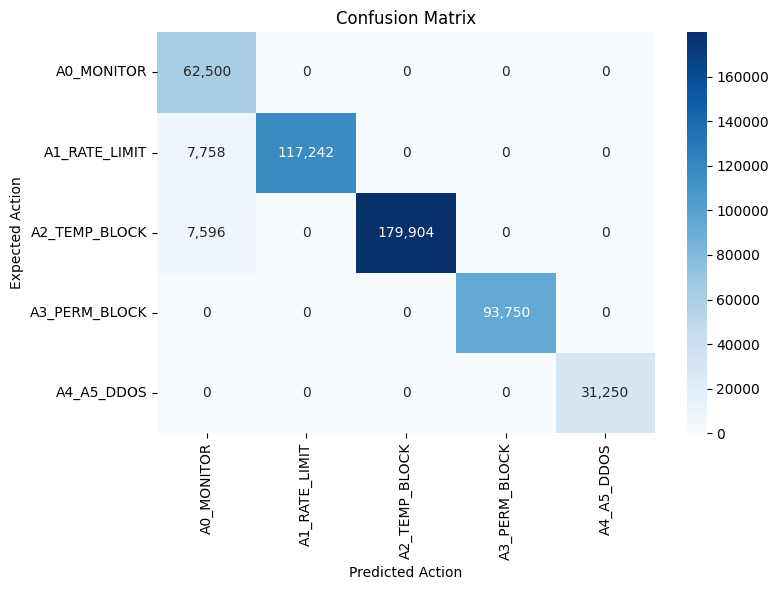

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm_df = pd.DataFrame(
    confusion,
    index=list(ACTION_NAMES.values()),
    columns=list(ACTION_NAMES.values())
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt=",.0f",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.ylabel("Expected Action")
plt.xlabel("Predicted Action")

plt.tight_layout()
plt.show()

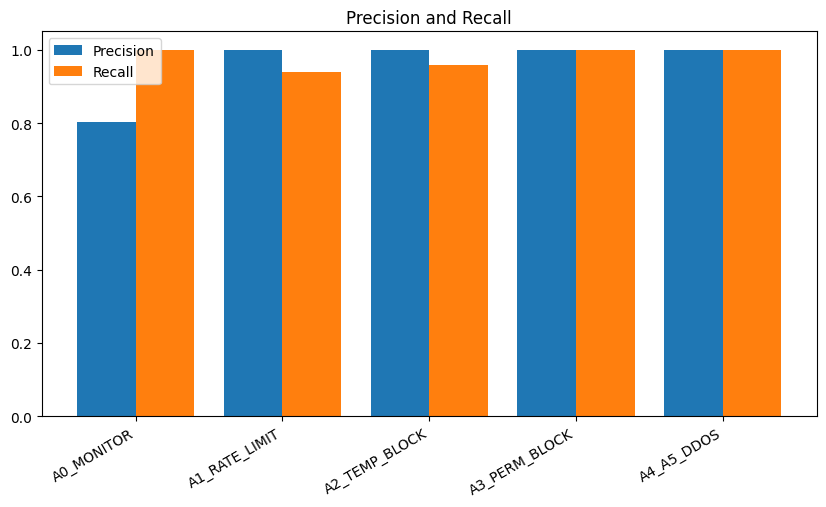

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
import matplotlib.pyplot as plt
import numpy as np

precision_list = []
recall_list = []

for a in range(N_ACTIONS):

    support = confusion[a,:].sum()
    predicted = confusion[:,a].sum()
    tp = confusion[a,a]

    precision = tp/predicted if predicted else 0
    recall = tp/support if support else 0

    precision_list.append(precision)
    recall_list.append(recall)

x = np.arange(len(ACTION_NAMES))

plt.figure(figsize=(10,5))

plt.bar(x-0.2, precision_list, 0.4, label="Precision")
plt.bar(x+0.2, recall_list, 0.4, label="Recall")

plt.xticks(
    x,
    list(ACTION_NAMES.values()),
    rotation=30,
    ha="right"
)

plt.ylim(0,1.05)

plt.legend()
plt.title("Precision and Recall")

plt.show()

In [ ]:
model.learn(
    total_timesteps=500_000,
    reset_num_timesteps=False
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.2      |
|    ep_rew_mean     | 45.5     |
| time/              |          |
|    fps             | 1367     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 507904   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2.12         |
|    ep_rew_mean          | 51.5         |
| time/                   |              |
|    fps                  | 1190         |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 512000       |
| train/                  |              |
|    approx_kl            | 0.0011274873 |
|    clip_fraction        | 0.0071       |
|    clip_range           | 0.2          |
|    clip_range_vf        | 0.2          |
|    entropy_loss         | -0.0627      |
|    explained_

In [ ]:
SAVE_DIR    = "/content/netknight_output"
model.save(f"{SAVE_DIR}/net_knight_rl_agent_16")
print(f"✅ Model saved → {SAVE_DIR}/net_knight_rl_agent_16.zip")

✅ Model saved → /content/netknight_output/net_knight_rl_agent_16.zip


In [ ]:
import os, time, random
import numpy as np
import torch as th
import torch.nn.functional as F
from collections import defaultdict

from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.maskable.evaluation import evaluate_policy as maskable_eval
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# Assumes the env/config cell has already run (IDSOutput, AnomalyOutput,
# IPHistory, NetworkState, NetKnightEnv, sample, recommended, build_state,
# get_mask, normalize_anomaly_score, ANOMALY_THRESHOLD, ACTION_NAMES,
# N_ACTIONS, A1_RATE_LIMIT, ...), exactly as the original training cell did.


# ── Shared: build the exact semantic objects a sampled scenario implies ─────
def _scenario_to_state(sc):
    """One place that turns a sample() dict into (ids, a_n, hist, net).
    Mirrors NetKnightEnv.reset() exactly. Reused by both the diagnostic
    and the calibration callback so there is one source of truth."""
    ids  = IDSOutput(sc["attack_type"], sc["ids_conf"], sc["protocol"])
    raw  = sc["anomaly_factor"] * ANOMALY_THRESHOLD[sc["model_key"]]
    anom = AnomalyOutput(raw, sc["model_key"])
    a_n  = normalize_anomaly_score(raw, sc["model_key"])

    if sc["init_rc"] > 0:
        hist = IPHistory(repeat_count=sc["init_rc"], same_attack_count=sc["init_rc"],
                          last_attack_type=sc["attack_type"], was_blocked=True,
                          last_action=A1_RATE_LIMIT)
    else:
        hist = IPHistory()

    net = NetworkState(dest_pressure_ratio=sc["dest_pressure"],
                        dest_new_conn_rate=sc["new_conn_rate"],
                        conns_active_dest=sc["conns"],
                        unique_sources=sc["unique_src"])
    return ids, anom, a_n, hist, net


# ── Diagnostic (unchanged from before — still the way to verify this is
#    actually working, not just assumed to be) ───────────────────────────────
def _diagnose_batch(model, rng, n):
    confusion = np.zeros((N_ACTIONS, N_ACTIONS), dtype=np.int64)  # [recommended][predicted]
    per_total, per_correct = defaultdict(int), defaultdict(int)

    for _ in range(n):
        sc = sample(rng)
        ids, anom, a_n, hist, net = _scenario_to_state(sc)
        obs  = build_state(ids, anom, hist, net)
        mask = np.array(get_mask(ids, a_n, hist, net), dtype=bool)
        rec  = recommended(ids, a_n, hist, net)

        pred, _ = model.predict(obs, action_masks=mask, deterministic=True)
        pred = int(pred)

        confusion[rec, pred] += 1
        per_total[sc["name"]] += 1
        if pred == rec:
            per_correct[sc["name"]] += 1

    return confusion, per_total, per_correct


def evaluate_decision_table_alignment(model, n_samples=5000, seed=123, verbose=True):
    rng = random.Random(seed)
    confusion, per_total, per_correct = _diagnose_batch(model, rng, n_samples)

    if verbose:
        header = "".join(f"{ACTION_NAMES[a]:>15s}" for a in range(N_ACTIONS))
        print(f"{'recommended -> predicted':26s}{header}")
        for r in range(N_ACTIONS):
            row = "".join(f"{confusion[r, p]:15d}" for p in range(N_ACTIONS))
            print(f"{ACTION_NAMES[r]:26s}{row}   (n={confusion[r].sum()})")

        print("\nPer-action precision / recall vs. decision table:")
        for a in range(N_ACTIONS):
            support, predicted, tp = confusion[a, :].sum(), confusion[:, a].sum(), confusion[a, a]
            precision = tp / predicted if predicted else float("nan")
            recall    = tp / support if support else float("nan")
            print(f"  {ACTION_NAMES[a]:14s} support={support:5d}  predicted={predicted:5d}  "
                  f"precision={precision:.2f}  recall={recall:.2f}")

        print(f"\nOverall decision-table match: {np.trace(confusion) / confusion.sum():.1%}")
        print("\nPer-scenario accuracy:")
        for name, total in sorted(per_total.items(), key=lambda kv: -kv[1]):
            print(f"  {name:18s} n={total:5d}  acc={per_correct[name] / total:.1%}")

    return confusion


# ── Symmetric, action-agnostic PPO stabilizers (kept from the prior pass) ───
class EntropyScheduleCallback(BaseCallback):
    """Linearly anneals ent_coef, symmetric over the whole action distribution."""
    def __init__(self, total_timesteps, start=0.02, end=0.003, verbose=0):
        super().__init__(verbose)
        self.total_timesteps = total_timesteps
        self.start, self.end = start, end

    def _on_step(self) -> bool:
        progress = min(max(self.num_timesteps / self.total_timesteps, 0.0), 1.0)
        self.model.ent_coef = self.start + (self.end - self.start) * progress
        return True


# ── THE ROOT-CAUSE FIX: symmetric decision-table calibration ────────────────
class DecisionTableCalibrationCallback(BaseCallback):
    """
    State-conditional calibration toward recommended(). Identical treatment
    for every action — there is no branch anywhere in this class that reads
    `action == A1_RATE_LIMIT` or `action == A2_TEMP_BLOCK`. The only signal
    is "what does the decision table say for THIS state", for whichever
    action that happens to be.

    Runs as a separate optimizer, separate from self.model.policy.optimizer
    (PPO's own). This means:
      - PPO's loss/advantages/GAE/clipping/target_kl are 100% untouched.
      - Setting aux_lr=0 (or dropping this callback) recovers the exact
        original training loop.
    """
    def __init__(self, calibrate_every=4096, batch_size=256, aux_lr=1e-4,
                 max_grad_norm=0.5, seed=2024, verbose=0):
        super().__init__(verbose)
        self.calibrate_every = calibrate_every
        self.batch_size = batch_size
        self.aux_lr = aux_lr
        self.max_grad_norm = max_grad_norm
        self.rng = random.Random(seed)
        self._last_calib = 0
        self._aux_opt = None

    def _init_callback(self) -> None:
        # Independent optimizer over the same policy params -- never
        # touches the main PPO optimizer's state or LR schedule.
        self._aux_opt = th.optim.Adam(self.model.policy.parameters(), lr=self.aux_lr)

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_calib < self.calibrate_every:
            return True
        self._last_calib = self.num_timesteps

        obs_batch, mask_batch, target_batch = [], [], []
        for _ in range(self.batch_size):
            sc = sample(self.rng)                      # same distribution PPO trains on
            ids, anom, a_n, hist, net = _scenario_to_state(sc)
            obs_batch.append(build_state(ids, anom, hist, net))
            mask_batch.append(get_mask(ids, a_n, hist, net))
            target_batch.append(recommended(ids, a_n, hist, net))   # ground truth, symmetric

        device = self.model.device
        obs_t    = th.as_tensor(np.array(obs_batch), dtype=th.float32, device=device)
        mask_t   = th.as_tensor(np.array(mask_batch), dtype=th.bool,  device=device)
        target_t = th.as_tensor(np.array(target_batch), dtype=th.long, device=device)

        policy = self.model.policy
        features = policy.extract_features(obs_t)
        latent_pi, _ = policy.mlp_extractor(features)
        logits = policy.action_net(latent_pi)

        # Never push probability toward a structurally disallowed action --
        # same mask the policy is evaluated against everywhere else.
        logits = logits.masked_fill(~mask_t, -1e8)

        loss = F.cross_entropy(logits, target_t)

        self._aux_opt.zero_grad()
        loss.backward()
        th.nn.utils.clip_grad_norm_(policy.parameters(), self.max_grad_norm)
        self._aux_opt.step()

        self.logger.record("calibration/aux_loss", loss.item())
        if self.verbose:
            print(f"[step {self.num_timesteps}] calibration aux_loss={loss.item():.4f}")
        return True


class ActionBalanceMonitor(BaseCallback):
    """Read-only: logs decision-table match rate + per-action predicted/table
    share. Doesn't alter gradients — lets you SEE whether calibration is
    actually moving the numbers instead of assuming it."""
    def __init__(self, eval_every=25_000, n_eval=1000, seed=777, verbose=0):
        super().__init__(verbose)
        self.eval_every = eval_every
        self.n_eval = n_eval
        self.rng = random.Random(seed)
        self._last_eval = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval < self.eval_every:
            return True
        self._last_eval = self.num_timesteps

        confusion, _, _ = _diagnose_batch(self.model, self.rng, self.n_eval)
        total = confusion.sum()
        acc = np.trace(confusion) / total
        pred_share  = confusion.sum(axis=0) / total
        table_share = confusion.sum(axis=1) / total

        self.logger.record("balance/decision_table_acc", float(acc))
        for a in range(N_ACTIONS):
            self.logger.record(f"balance/pred_share_{ACTION_NAMES[a]}", float(pred_share[a]))
            self.logger.record(f"balance/table_share_{ACTION_NAMES[a]}", float(table_share[a]))

        if self.verbose:
            shares = {ACTION_NAMES[a]: round(float(pred_share[a]), 2) for a in range(N_ACTIONS)}
            print(f"[step {self.num_timesteps}] decision-table acc={acc:.1%}  pred_share={shares}")
        return True


# # ── Training loop ─────────────────────────────────────────────────────────────
# SAVE_DIR    = "/content/netknight_output"
# TOTAL_STEPS = 500_000
# N_ENVS      = 8

# os.makedirs(SAVE_DIR, exist_ok=True)

# vec_env = DummyVecEnv(
#     [lambda i=i: Monitor(NetKnightEnv(seed=i)) for i in range(N_ENVS)]
# )

# model = MaskablePPO(
#     MaskableActorCriticPolicy,
#     vec_env,
#     learning_rate=3e-4,
#     n_steps=512,
#     batch_size=256,
#     n_epochs=10,
#     gamma=0.97,
#     gae_lambda=0.95,
#     clip_range=0.2,
#     ent_coef=0.02,               # entropy schedule start; symmetric, all 5 actions
#     target_kl=0.03,              # caps destabilizing PPO updates
#     normalize_advantage=True,    # real batch-wide normalization, action-agnostic
#     policy_kwargs=dict(net_arch=[256, 256]),
#     verbose=1,
#     seed=0,
# )

# # PARAMS TO TUNE: if training feels like it's drifting toward pure table
# # imitation (entropy collapsing fast, reward plateauing lower than the
# # original run), lower aux_lr and/or increase calibrate_every first.
# callbacks = [
#     EntropyScheduleCallback(total_timesteps=TOTAL_STEPS, start=0.02, end=0.003, verbose=1),
#     DecisionTableCalibrationCallback(calibrate_every=4096, batch_size=256,
#                                       aux_lr=0, verbose=1),
#     ActionBalanceMonitor(eval_every=25_000, n_eval=1000, verbose=1),
# ]

# t0 = time.time()
# model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True, callback=callbacks)
# elapsed = (time.time() - t0) / 60
# print(f"\n⏱️  Training done in {elapsed:.1f} min")

# model.save(f"{SAVE_DIR}/net_knight_rl_agent")
# print(f"✅ Model saved → {SAVE_DIR}/net_knight_rl_agent.zip")

# _eval_env = Monitor(NetKnightEnv(seed=9999))
# mean_r, std_r = maskable_eval(model, _eval_env, n_eval_episodes=500, warn=False)
# print(f"📊 Eval (500 ep) → mean_reward = {mean_r:.2f} ± {std_r:.2f}")

# confusion = evaluate_decision_table_alignment(model, n_samples=5000)

# ── Optional refinement (not implemented, left as a next step) ──────────────
# If per-scenario accuracy above shows the remaining error concentrated in
# specific boundary regimes (e.g. rc==1 vs rc==2, or ids_conf near 0.6),
# the calibration cross-entropy can be reweighted per-example with a
# focal-loss-style term (1 - p_target)**gamma to focus updates on states
# the policy currently gets wrong, without touching which action is being
# corrected toward -- i.e. option 4, layered on top of this, still fully
# symmetric. Worth adding only if the diagnostic shows it's needed.

In [ ]:
# ## Cell 10 — Inference Example (for VM Backend / Network Security Team)
#
# CHANGES (v6):
#   • make_ids() no longer accepts or returns severity
#   • NetworkState constructed without bandwidth/cpu for RL; add them separately
#     if you need them for the dashboard layer (get_final_severity)
#   • HistoryStore.update() now increments repeat_count on every flow observation

INFERENCE_EXAMPLE = '''
from sb3_contrib import MaskablePPO

rl_model = MaskablePPO.load("net_knight_rl_agent.zip")
history  = HistoryStore()

def get_rl_action(
    ids_label:      str,          # from LightGBM: e.g. "Brute Force"
    ids_confidence: float,        # from predict_proba
    anomaly_resp:   dict,         # from Anomaly FastAPI: {"model":"NonWebTcp","anomaly_score":5.3,...}
    flow_metadata:  dict,         # {"src_ip":"1.2.3.4","dst_ip":"5.6.7.8","protocol":6,...}
    net_state:      NetworkState, # dest_pressure_ratio, dest_new_conn_rate, conns_active_dest, unique_sources
) -> tuple:
    """
    Returns (action_int, action_name, severity_label) where:
      • action_int / action_name → sent to nftables by the network security team
      • severity_label           → sent to dashboard / alert system (NEVER used for RL decision)
    """
    ids  = make_ids(ids_label, ids_confidence, flow_metadata.get("protocol", 6))
    anom = make_anomaly(anomaly_resp)
    hist = history.get(flow_metadata["src_ip"])

    # ── RL decision (no severity involved) ────────────────────────────────────
    obs  = build_state(ids, anom, hist, net_state)
    a_n  = normalize_anomaly_score(anom.raw_score, anom.model_key)
    mask = np.array(get_mask(ids, a_n, hist, net_state), dtype=bool)

    action, _ = rl_model.predict(obs, action_masks=mask, deterministic=True)
    action     = int(action)

    # ── History update — repeat_count incremented every observation ───────────
    history.update(flow_metadata["src_ip"], action)

    # ── Dashboard severity (computed AFTER RL decision, never influences it) ──
    severity = get_final_severity(ids.attack_type, a_n)

    return action, ACTION_NAMES[action], severity

# Example call:
# action_int, action_name, severity = get_rl_action(
#     ids_label      = "Brute Force",
#     ids_confidence = 0.87,
#     anomaly_resp   = {"model":"NonWebTcp","anomaly_score":5.4,"is_anomaly":True},
#     flow_metadata  = {flow_id,time,"src_ip":"192.168.1.100",src_port,dst_port,"dst_ip":"10.0.0.1","protocol":6},
#     net_state      = NetworkState(
#                          dest_pressure_ratio=1.5,
#                          dest_new_conn_rate=15.0,
#                          conns_active_dest=20,
#                          unique_sources=1,
#                          # set them here if you want them in the dashboard alert
#                      ),
# )
# print(action_name)  # → "A1_RATE_LIMIT"
# print(severity)     # → "MEDIUM"  (dashboard only — did NOT affect the RL decision)
'''
print(INFERENCE_EXAMPLE)



from sb3_contrib import MaskablePPO

rl_model = MaskablePPO.load("net_knight_rl_agent.zip")
history  = HistoryStore()

def get_rl_action(
    ids_label:      str,          # from LightGBM: e.g. "Brute Force"
    ids_confidence: float,        # from predict_proba
    anomaly_resp:   dict,         # from Anomaly FastAPI: {"model":"NonWebTcp","anomaly_score":5.3,...}
    flow_metadata:  dict,         # {"src_ip":"1.2.3.4","dst_ip":"5.6.7.8","protocol":6,...}
    net_state:      NetworkState, # dest_pressure_ratio, dest_new_conn_rate, conns_active_dest, unique_sources
) -> tuple:
    """
    Returns (action_int, action_name, severity_label) where:
      • action_int / action_name → sent to nftables by the network security team
      • severity_label           → sent to dashboard / alert system (NEVER used for RL decision)
    """
    ids  = make_ids(ids_label, ids_confidence, flow_metadata.get("protocol", 6))
    anom = make_anomaly(anomaly_resp)
    hist = history.get(flow_metadata["src_